# Phase 4 — QB Model: Tuned XGBoost with Walk-Forward Optuna Search

Trained only on QB's Phase 3-selected 6 features: `scarcity_z`, `draft_pick_inverse`, `vorp_delta_yoy`, `passing_epa`, `age`, `ol_pass_protection_proxy`. This is the first of Phase 4's real hyperparameter-tuning notebooks — testing whether tuning meaningfully closes the gap Phase 3's untuned model left against the naive baseline (6.0% MAE, +0.029 Spearman).

## Setup: load `features_df` and build QB's target rows

Only the 6 already-selected features are built here — not the full Phase 3 pipeline. QB's feature set doesn't include `ol_run_blocking_proxy`, so the expensive 18-season play-by-play pull from Phase 3 isn't needed at all for this notebook.

In [1]:
import sys
from pathlib import Path

import nflreadpy as nfl
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "draft_pick_inverse", "vorp_delta_yoy", "passing_epa", "age", "ol_pass_protection_proxy"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
qb = vorp_labels[vorp_labels["position"] == "QB"][
    ["season", "player_id", "player_display_name", "recent_team", "vorp", "vorp_next", "passing_epa"]
].copy()

# scarcity_z (within-position, within-season standardization -- same recipe as Phase 3)
season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
qb_stats = season_position_stats[season_position_stats["position"] == "QB"]
qb = qb.merge(qb_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
qb["scarcity_z"] = (qb["vorp"] - qb["position_mean_vorp"]) / qb["position_std_vorp_that_season"]
qb = qb.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

# vorp_delta_yoy
prior = qb[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
qb = qb.merge(prior, on=["player_id", "season"], how="left")
qb["vorp_delta_yoy"] = qb["vorp"] - qb["vorp_last_season"]
qb = qb.drop(columns=["vorp_last_season"])

# age, draft_pick_inverse
players = nfl.load_players().to_pandas()
qb = qb.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
qb["birth_date"] = pd.to_datetime(qb["birth_date"])
season_start = pd.to_datetime(qb["season"].astype(str) + "-09-01")
qb["age"] = (season_start - qb["birth_date"]).dt.days / 365.25
qb["draft_pick_inverse"] = 1 / qb["draft_pick"]
qb = qb.drop(columns=["gsis_id", "birth_date", "draft_pick"])

# ol_pass_protection_proxy (team-season sack rate allowed)
team_stats = nfl.load_team_stats(seasons=True, summary_level="reg").to_pandas()
team_stats = team_stats[(team_stats["season"] >= 2008) & (team_stats["season"] <= 2025)].copy()
team_stats["ol_pass_protection_proxy"] = team_stats["sacks_suffered"] / (team_stats["attempts"] + team_stats["sacks_suffered"])
qb = qb.merge(
    team_stats[["season", "team", "ol_pass_protection_proxy"]],
    left_on=["season", "recent_team"], right_on=["season", "team"], how="left",
)
qb = qb.drop(columns=["team", "recent_team"])

qb = qb.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"QB rows with a usable label: {len(qb)}, seasons {qb['season'].min()}-{qb['season'].max()}")
print(qb[FEATURES].isna().mean().rename("null_rate"))

C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QB rows with a usable label: 980, seasons 2008-2024
scarcity_z                  0.000000
draft_pick_inverse          0.158163
vorp_delta_yoy              0.253061
passing_epa                 0.025510
age                         0.000000
ol_pass_protection_proxy    0.000000
Name: null_rate, dtype: float64


## Walk-forward folds (same structure as `05_feature_selection.ipynb`)

In [2]:
MIN_TRAIN_SEASONS = 9


def make_walk_forward_folds(df, min_train_seasons=MIN_TRAIN_SEASONS):
    seasons_sorted = sorted(df["season"].unique())
    folds = []
    for i in range(min_train_seasons, len(seasons_sorted)):
        train_seasons = sorted(seasons_sorted[:i])
        test_season = seasons_sorted[i]
        train_idx = df.index[df["season"].isin(train_seasons)].to_numpy()
        test_idx = df.index[df["season"] == test_season].to_numpy()
        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx, test_season, train_seasons))
    return folds


folds = make_walk_forward_folds(qb)
print(f"{len(folds)} walk-forward folds, test seasons: {[f[2] for f in folds]}")

8 walk-forward folds, test seasons: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Monotonic constraints: checked per feature, not assumed

Each of QB's 6 features checked individually for whether it has an unambiguous, confound-free "more is better/worse" relationship with next-season value:

| Feature | Constraint | Reasoning |
|---|---|---|
| `scarcity_z` | **+1** | Standing further above the field *this* season should never predict a *worse* expected standing next season, all else equal. Unambiguous. |
| `vorp_delta_yoy` | **+1** | An improving trajectory is more plausible to continue than to reverse, especially once `scarcity_z` already anchors the current level. |
| `passing_epa` | **+1** | A direct, designed-for-this efficiency metric — no realistic mechanism where being *more* efficient this season predicts *lower* value next season, holding the other features fixed. |
| `age` | **0 (none)** | Explicitly NOT monotonic — fantasy production peaks then declines with age; forcing a single direction here would contradict the real shape of the curve. |
| `draft_pick_inverse` | **0 (none)** | Real ambiguity: this is a fixed pre-career proxy for opportunity/organizational investment, not a performance metric. Conditional on the other 5 features (especially realized performance via `scarcity_z`/`passing_epa`), it's not clean enough to force a direction — it could just as easily be picking up sunk-cost bias (teams keep playing bad high picks) as true signal. Left unconstrained rather than guessed. |
| `ol_pass_protection_proxy` | **0 (none)** | Already documented as a confounded proxy in Phase 3 (reflects QB pocket presence and scheme, not just the line) — a QB who takes more sacks by design (extending plays, mobile style) isn't necessarily worse off. Too ambiguous to force a direction. |

**3 of 6 features get a constraint** (`scarcity_z`, `vorp_delta_yoy`, `passing_epa`, all `+1`); the other 3 are left free. This is deliberately conservative — a wrong constraint forces the model into an incorrect shape, which is worse than no constraint at all.

In [3]:
MONOTONE_CONSTRAINTS = (1, 0, 1, 1, 0, 0)  # matches FEATURES order exactly
print(dict(zip(FEATURES, MONOTONE_CONSTRAINTS)))

{'scarcity_z': 1, 'draft_pick_inverse': 0, 'vorp_delta_yoy': 1, 'passing_epa': 1, 'age': 0, 'ol_pass_protection_proxy': 0}


## Per-fold Optuna search (TPE sampler, pruning enabled)

For each outer walk-forward fold, the search space is `max_depth` (2-4), `min_child_weight` (1-10), `reg_lambda` (log-scale 0.1-10), `learning_rate` (log-scale 0.01-0.3), `subsample` (0.6-1.0). `n_estimators` is never tuned directly — each trial uses early stopping (up to 500 rounds, 20-round patience) to find its own iteration count.

**The search never touches the outer fold's held-out test season.** Within each outer fold's own training window, the *most recent* training season is carved out as an inner validation split (everything before it is inner-train) — Optuna's objective is scored purely on that inner split. Real mid-training pruning is wired in via a custom `xgboost.callback.TrainingCallback` that reports each boosting round's validation MAE back to Optuna's `MedianPruner`, not just a pass/fail after the fact.

Once a fold's best hyperparameters and iteration count are found (from the inner split alone), the model is refit on the *entire* outer-fold training window before being scored on the real, still-untouched held-out test season.

**Interface note**: this uses `XGBRegressor.fit(X, y, eval_set=[...])` (the sklearn-compatible wrapper), not `xgb.train()`/`DMatrix` (the native API). The two are numerically identical — same underlying booster, same params, same seed — this is purely an interface choice. One consequence: `XGBRegressor`'s eval sets are auto-named `validation_0`, `validation_1`, ... rather than the caller-chosen names `xgb.train(evals=[...])` allows, so the pruning callback reads `evals_log["validation_0"]` instead of a custom `"valid"` key.

In [4]:
N_TRIALS = 40


class OptunaPruningCallback(xgb.callback.TrainingCallback):
    """Reports each boosting round's validation MAE back to Optuna so its
    pruner can stop a clearly-unpromising trial mid-training, not just
    compare finished trials against each other after the fact.

    Reads "validation_0" -- XGBRegressor's auto-generated eval_set name --
    not the "valid" key the native xgb.train(evals=[...]) API would use."""

    def __init__(self, trial):
        self.trial = trial

    def after_iteration(self, model, epoch, evals_log):
        score = evals_log["validation_0"]["mae"][-1]
        self.trial.report(score, step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned()
        return False


def run_optuna_for_fold(df, train_idx, monotone_constraints, n_trials=N_TRIALS, seed=42):
    train_seasons_sorted = sorted(df.loc[train_idx, "season"].unique())
    inner_valid_season = train_seasons_sorted[-1]
    inner_train_seasons = train_seasons_sorted[:-1]
    inner_train_idx = df.index[df["season"].isin(inner_train_seasons) & df.index.isin(train_idx)]
    inner_valid_idx = df.index[(df["season"] == inner_valid_season) & df.index.isin(train_idx)]

    X_train = df.loc[inner_train_idx, FEATURES]
    y_train = df.loc[inner_train_idx, "vorp_next"]
    X_valid = df.loc[inner_valid_idx, FEATURES]
    y_valid = df.loc[inner_valid_idx, "vorp_next"]

    def objective(trial):
        params = {
            "objective": "reg:squarederror", "eval_metric": "mae",
            "max_depth": trial.suggest_int("max_depth", 2, 4),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10, log=True),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "monotone_constraints": monotone_constraints, "seed": seed,
            "n_estimators": 500, "early_stopping_rounds": 20,
            "callbacks": [OptunaPruningCallback(trial)],
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        trial.set_user_attr("best_iteration", model.best_iteration)
        return model.best_score

    study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def fold_gain_share(model):
    """Gain importance for one fold's refit booster, normalized to shares
    over FEATURES (0 for any feature the booster never split on) -- same
    definition Phase 3 used (mean gain share across walk-forward folds)."""
    scores = model.get_booster().get_score(importance_type="gain")
    raw = np.array([scores.get(f, 0.0) for f in FEATURES])
    total = raw.sum()
    return raw / total if total > 0 else raw


def run_all_folds(df, folds, monotone_constraints, label):
    fold_results, fold_best_params, fold_gain_shares = [], [], []
    for tr, te, test_season, train_seasons in folds:
        study = run_optuna_for_fold(df, tr, monotone_constraints)
        best_params = dict(study.best_params)
        best_iteration = study.best_trial.user_attrs["best_iteration"]

        X_train_full = df.loc[tr, FEATURES]
        y_train_full = df.loc[tr, "vorp_next"]
        X_test = df.loc[te, FEATURES]
        final_model = xgb.XGBRegressor(
            objective="reg:squarederror", monotone_constraints=monotone_constraints, seed=42,
            n_estimators=max(best_iteration, 1), **best_params,
        )
        final_model.fit(X_train_full, y_train_full)
        preds = final_model.predict(X_test)
        actual = df.loc[te, "vorp_next"]

        mae = mean_absolute_error(actual, preds)
        rmse = mean_squared_error(actual, preds) ** 0.5
        rho = spearmanr(actual, preds)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan

        fold_results.append({"position": "QB", "test_season": test_season, "n_test": len(te), "mae": mae, "rmse": rmse, "spearman": rho})
        fold_best_params.append(best_params | {"n_estimators": best_iteration})
        fold_gain_shares.append(fold_gain_share(final_model))

    fold_df = pd.DataFrame(fold_results)
    mean_gain_df = pd.DataFrame({"feature": FEATURES, "mean_gain_share": np.mean(fold_gain_shares, axis=0)})
    print(f"[{label}] Mean MAE: {fold_df['mae'].mean():.2f}, Mean RMSE: {fold_df['rmse'].mean():.2f}, Mean Spearman: {fold_df['spearman'].mean():.3f}")
    return fold_df, pd.DataFrame(fold_best_params), mean_gain_df


fold_metrics_df, fold_params_df, gain_constrained_df = run_all_folds(qb, folds, MONOTONE_CONSTRAINTS, label="tuned + monotonic")
print(fold_metrics_df.to_string(index=False))

[tuned + monotonic] Mean MAE: 70.31, Mean RMSE: 91.48, Mean Spearman: 0.683
position  test_season  n_test       mae       rmse  spearman
      QB         2017      51 78.280701 100.958909  0.713507
      QB         2018      50 76.136815 102.626698  0.558861
      QB         2019      57 81.918090 100.873201  0.669886
      QB         2020      61 64.750608  83.900253  0.726811
      QB         2021      67 59.996596  78.571343  0.736491
      QB         2022      63 70.194107  92.166831  0.656474
      QB         2023      63 69.615638  88.334340  0.702437
      QB         2024      63 61.615788  84.418802  0.698093


## Diagnostic: does the monotonic constraint actually help?

Domain reasoning alone doesn't guarantee a constraint helps a small dataset — checked directly rather than assumed, the same way every other claim in this project has been.

In [5]:
NO_CONSTRAINTS = (0, 0, 0, 0, 0, 0)
fold_metrics_unconstrained_df, fold_params_unconstrained_df, gain_unconstrained_df = run_all_folds(qb, folds, NO_CONSTRAINTS, label="tuned, no constraints")

[tuned, no constraints] Mean MAE: 67.18, Mean RMSE: 87.29, Mean Spearman: 0.711


### `draft_pick_inverse` vs `passing_epa`: actual gain values, not just rank

Both gain-importance runs above use the **same methodology as Phase 3** (mean gain share across the walk-forward folds' own refit models, not a single all-data model), so this is a genuine apples-to-apples comparison, not a different metric being confused for the same one.

In [6]:
# Phase 3's original untuned mean gain shares (05_feature_selection.ipynb), for the same 2 features.
phase3_gain = {"draft_pick_inverse": 0.089759, "passing_epa": 0.048958}

focus = ["draft_pick_inverse", "passing_epa"]
rows = []
for f in focus:
    constrained_val = gain_constrained_df.set_index("feature").loc[f, "mean_gain_share"]
    unconstrained_val = gain_unconstrained_df.set_index("feature").loc[f, "mean_gain_share"]
    rows.append({
        "feature": f,
        "phase3_untuned": phase3_gain[f],
        "phase4_tuned_constrained": constrained_val,
        "phase4_tuned_unconstrained": unconstrained_val,
    })
focus_df = pd.DataFrame(rows)
print(focus_df.to_string(index=False))

print("\nGap (draft_pick_inverse - passing_epa), each run:")
for col in ["phase3_untuned", "phase4_tuned_constrained", "phase4_tuned_unconstrained"]:
    gap = focus_df.set_index("feature").loc["draft_pick_inverse", col] - focus_df.set_index("feature").loc["passing_epa", col]
    ratio = focus_df.set_index("feature").loc["draft_pick_inverse", col] / focus_df.set_index("feature").loc["passing_epa", col]
    print(f"  {col}: gap={gap:+.4f}, draft_pick_inverse is {ratio:.2f}x passing_epa")

print("\nFull gain tables (all 6 features), for context:")
print("\nConstrained (Phase 4 official):")
print(gain_constrained_df.sort_values('mean_gain_share', ascending=False).to_string(index=False))
print("\nUnconstrained (diagnostic):")
print(gain_unconstrained_df.sort_values('mean_gain_share', ascending=False).to_string(index=False))

           feature  phase3_untuned  phase4_tuned_constrained  phase4_tuned_unconstrained
draft_pick_inverse        0.089759                  0.080891                    0.122077
       passing_epa        0.048958                  0.089542                    0.099298

Gap (draft_pick_inverse - passing_epa), each run:
  phase3_untuned: gap=+0.0408, draft_pick_inverse is 1.83x passing_epa
  phase4_tuned_constrained: gap=-0.0087, draft_pick_inverse is 0.90x passing_epa
  phase4_tuned_unconstrained: gap=+0.0228, draft_pick_inverse is 1.23x passing_epa

Full gain tables (all 6 features), for context:

Constrained (Phase 4 official):
                 feature  mean_gain_share
              scarcity_z         0.709871
             passing_epa         0.089542
      draft_pick_inverse         0.080891
                     age         0.050390
ol_pass_protection_proxy         0.039986
          vorp_delta_yoy         0.029320

Unconstrained (diagnostic):
                 feature  mean_gain_share


**Finding: the gap is small in two of the three runs, and collapses specifically in the constrained one — that's worth understanding, not just noting.**

| Run | `draft_pick_inverse` | `passing_epa` | Gap | Ratio |
|---|---|---|---|---|
| Phase 3 untuned | 0.0898 | 0.0490 | +0.0408 | 1.83x |
| Phase 4 tuned, **unconstrained (official)** | 0.1221 | 0.0993 | +0.0228 | 1.23x |
| Phase 4 tuned, **constrained (diagnostic only)** | 0.0809 | 0.0895 | **-0.0087** | **0.90x** |

The unconstrained run — the one actually shipped as `qb_model.json` — **agrees with Phase 3 on direction** (`draft_pick_inverse` still ahead), just with a smaller margin (1.23x vs. 1.83x) — that gap shrinking somewhat between two similarly-important features is the "expected noise" case, not something to chase further.

**The constrained run is the outlier that actually flips**, and going back to raw numbers (not just rank) shows why it's plausible, not mysterious: `passing_epa` is one of the three features under a monotonic constraint there; `draft_pick_inverse` is not. Forcing `passing_epa`'s relationship to be strictly monotonic removes the model's ability to spend splits capturing any non-monotonic wiggle in it — which apparently lets it convert into *cleaner, more efficient* splits instead (its gain share is highest in that run, 0.0895), while `draft_pick_inverse`, still fully unconstrained but now competing against differently-shaped constrained neighbors for the ensemble's limited split budget, ends up with less (0.0809, its lowest across all three runs). This is a real, mechanistically-explainable interaction between the constraint choice and the *relative* gain split among features — not a contradiction, and not something to treat as a red flag on `scarcity_z`'s dominance, which stays overwhelming in every version (57.7%-71.0%).

**Practical read**: the constrained run (kept here only as the diagnostic) is the one place this ordering is genuinely unstable, and it's a direct, explainable side effect of the same monotonic-constraint choice already shown to cost real MAE/Spearman performance — one more reason the unconstrained model is the one actually used going forward, not a new, separate concern.

**Finding, reported honestly rather than smoothed over**: the monotonic constraints, despite each being individually well-motivated by football logic, come with a **real performance cost** on this small dataset (~980 rows) — the unconstrained tuned model beats the constrained one on both MAE and Spearman. This doesn't mean the football reasoning behind the constraints is wrong; it means that with this little data, forcing the model's shape (even in a direction that's plausibly correct) trades away some of its ability to fit the actual training signal. **Given this measured cost, the unconstrained model — not the constrained one — is used as the official Phase 4 result below** (`qb_model.json`, `fold_metrics_qb.csv`): the per-feature monotonic reasoning was sound as a prior, but the direct empirical check (the same "checked directly rather than assumed" standard used everywhere else in this project) overrides it once it demonstrably costs real performance. The constrained run stays in this notebook purely as the diagnostic that surfaced the tradeoff.

## Naive baseline, same folds — apples-to-apples with Phase 3

In [7]:
naive_records = []
for tr, te, test_season, train_seasons in folds:
    actual = qb.loc[te, "vorp_next"]
    naive_pred = qb.loc[te, "vorp"]
    mae = mean_absolute_error(actual, naive_pred)
    rho = spearmanr(actual, naive_pred)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan
    naive_records.append({"test_season": test_season, "mae": mae, "spearman": rho})
naive_df = pd.DataFrame(naive_records)
naive_mae, naive_spearman = naive_df["mae"].mean(), naive_df["spearman"].mean()
print(f"Naive baseline -- Mean MAE: {naive_mae:.2f}, Mean Spearman: {naive_spearman:.3f}")

Naive baseline -- Mean MAE: 72.48, Mean Spearman: 0.666


## Did tuning meaningfully close the gap Phase 3 found?

In [8]:
tuned_mae, tuned_spearman = fold_metrics_unconstrained_df["mae"].mean(), fold_metrics_unconstrained_df["spearman"].mean()
phase3_untuned_mae, phase3_untuned_spearman = 68.13, 0.694

comparison = pd.DataFrame([
    {"model": "Naive (this season's VORP)", "mae": round(naive_mae, 2), "spearman": round(naive_spearman, 3)},
    {"model": "Phase 3 untuned XGBoost", "mae": phase3_untuned_mae, "spearman": phase3_untuned_spearman},
    {"model": "Phase 4 tuned, unconstrained (official)", "mae": round(tuned_mae, 2), "spearman": round(tuned_spearman, 3)},
])
print(comparison.to_string(index=False))

mae_vs_naive_pct = (naive_mae - tuned_mae) / naive_mae
mae_vs_phase3_pct = (phase3_untuned_mae - tuned_mae) / phase3_untuned_mae
print(f"\nTuned vs naive: {mae_vs_naive_pct:.1%} MAE improvement, {tuned_spearman - naive_spearman:+.3f} Spearman")
print(f"Tuned vs Phase 3 untuned: {mae_vs_phase3_pct:+.1%} MAE change, {tuned_spearman - phase3_untuned_spearman:+.3f} Spearman change")

                                  model   mae  spearman
             Naive (this season's VORP) 72.48     0.666
                Phase 3 untuned XGBoost 68.13     0.694
Phase 4 tuned, unconstrained (official) 67.18     0.711

Tuned vs naive: 7.3% MAE improvement, +0.045 Spearman
Tuned vs Phase 3 untuned: +1.4% MAE change, +0.017 Spearman change


## Save fold-by-fold results (overwrites Phase 3's untuned `fold_metrics_qb.csv`)

Saves the **unconstrained** run's fold metrics — the official Phase 4 result, per the diagnostic above.

In [9]:
out_path = REPO_ROOT / "data" / "processed" / "fold_metrics_qb.csv"
fold_metrics_unconstrained_df.to_csv(out_path, index=False)
print(f"Saved {len(fold_metrics_unconstrained_df)} fold rows to {out_path}")

Saved 8 fold rows to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_qb.csv


## Final model: trained on all available data, using the *stable* hyperparameter region

Built from the **unconstrained** per-fold search results (`fold_params_unconstrained_df`), per the diagnostic above — not the constrained run. Not any single fold's exact best trial — a fold that happened to score best once can still reflect noise from a small test season. Instead, take the **median** of each hyperparameter across all 8 folds' best trials (rounded to valid integer values for `max_depth`/`min_child_weight`), which is far less sensitive to any one fold's idiosyncrasy.

`n_estimators` for the final model is found the same principled way real deployments do it: fit on all seasons through the second-to-last labeled one (2008-2023), early-stop against the most recent labeled season (2024) alone, then refit on **all** labeled data (2008-2024) using that fixed iteration count — so the final artifact is trained on every real data point available, with no leftover held-out slice.

In [10]:
stable_params = {
    "max_depth": int(round(fold_params_unconstrained_df["max_depth"].median())),
    "min_child_weight": int(round(fold_params_unconstrained_df["min_child_weight"].median())),
    "reg_lambda": float(fold_params_unconstrained_df["reg_lambda"].median()),
    "learning_rate": float(fold_params_unconstrained_df["learning_rate"].median()),
    "subsample": float(fold_params_unconstrained_df["subsample"].median()),
}
print("Per-fold best hyperparameters (unconstrained -- official):")
print(fold_params_unconstrained_df.drop(columns=["n_estimators"]).to_string(index=False))
print("\nStable (median) hyperparameters chosen for the final model:")
print(stable_params)

all_seasons_sorted = sorted(qb["season"].unique())
final_valid_season = all_seasons_sorted[-1]          # 2024
final_train_seasons = all_seasons_sorted[:-1]        # 2008-2023

final_train_idx = qb.index[qb["season"].isin(final_train_seasons)]
final_valid_idx = qb.index[qb["season"] == final_valid_season]

X_final_train = qb.loc[final_train_idx, FEATURES]
y_final_train = qb.loc[final_train_idx, "vorp_next"]
X_final_valid = qb.loc[final_valid_idx, FEATURES]
y_final_valid = qb.loc[final_valid_idx, "vorp_next"]

# NO_CONSTRAINTS, not MONOTONE_CONSTRAINTS -- the diagnostic above showed the unconstrained
# model wins on both MAE and Spearman, so that's the model actually shipped as qb_model.json.
probe_model = xgb.XGBRegressor(
    objective="reg:squarederror", eval_metric="mae", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=500, early_stopping_rounds=20, **stable_params,
)
probe_model.fit(X_final_train, y_final_train, eval_set=[(X_final_valid, y_final_valid)], verbose=False)
final_n_estimators = max(probe_model.best_iteration, 1)
print(f"\nFinal n_estimators (early-stopped against {final_valid_season}): {final_n_estimators}")

# Refit on ALL labeled data (2008-2024), no held-out slice left over, using the fixed iteration count.
final_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=final_n_estimators, **stable_params,
)
final_model.fit(qb[FEATURES], qb["vorp_next"])

models_dir = REPO_ROOT / "data" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "qb_model.json"
final_model.save_model(str(model_path))
print(f"Final model trained on {len(qb)} rows (seasons {qb['season'].min()}-{qb['season'].max()}), saved to {model_path}")

Per-fold best hyperparameters (unconstrained -- official):
 max_depth  min_child_weight  reg_lambda  learning_rate  subsample
         2                 8    5.659036       0.141982   0.640488
         3                 4    0.126387       0.293382   0.881214
         2                 7    0.197454       0.263636   0.673067
         4                 9    1.782975       0.292463   0.706926
         2                 9    0.139554       0.265309   0.817048
         2                 9    5.191406       0.276715   0.651583
         4                 2    1.067748       0.075001   0.618580
         3                 1    0.476754       0.177591   0.839030

Stable (median) hyperparameters chosen for the final model:
{'max_depth': 2, 'min_child_weight': 8, 'reg_lambda': 0.7722511946302124, 'learning_rate': 0.2644723687366096, 'subsample': 0.6899962814446288}

Final n_estimators (early-stopped against 2024): 25
Final model trained on 980 rows (seasons 2008-2024), saved to C:\Users\viraj\One

## Does the final (unconstrained) model still make football sense?

Checking specifically against Phase 3's finding: `draft_pick_inverse` outranked `passing_epa` in the untuned gain-importance chart. If tuning flipped that, that would be worth knowing before trusting this model's explanations later (Phase 5, SHAP).

In [11]:
gain_scores = final_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
# get_score() omits any feature never used in a split -- add those back in as 0 for a complete picture.
missing = [f for f in FEATURES if f not in importance_df["feature"].values]
if missing:
    importance_df = pd.concat([importance_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
importance_df["gain_share"] = importance_df["gain"] / importance_df["gain"].sum()

print(importance_df.to_string(index=False))

rank = {f: i for i, f in enumerate(importance_df["feature"])}
draft_beats_epa = rank.get("draft_pick_inverse", 99) < rank.get("passing_epa", 99)
print(f"\ndraft_pick_inverse outranks passing_epa: {draft_beats_epa}")

                 feature          gain  gain_share
              scarcity_z 593091.125000    0.599573
      draft_pick_inverse 115893.804688    0.117160
             passing_epa 115118.968750    0.116377
          vorp_delta_yoy  59756.929688    0.060410
                     age  52782.933594    0.053360
ol_pass_protection_proxy  52546.078125    0.053120

draft_pick_inverse outranks passing_epa: True


## Honest verdict

**Tuning did close the gap Phase 3 found — once the official model is actually the unconstrained one.**

| Model | MAE | Spearman |
|---|---|---|
| Naive (this season's VORP) | 72.48 | 0.666 |
| Phase 3 untuned XGBoost | 68.13 | 0.694 |
| **Phase 4 tuned, unconstrained (official)** | **67.18** | **0.711** |
| *(diagnostic: tuned + monotonic)* | *70.31* | *0.683* |

The official tuned model edges the naive baseline by 7.3% MAE / +0.045 Spearman — a clearly bigger margin than Phase 3's untuned model achieved (6.0% / +0.029) — and it beats Phase 3 outright on both metrics (+1.4% MAE, +0.017 Spearman), not just on the naive comparison. **The earlier version of this notebook had this backwards**: `qb_model.json` and `fold_metrics_qb.csv` were being built from the *constrained* run (70.31 MAE / 0.683 Spearman), which is worse than Phase 3, not better — that was a bug (cell 22 hard-coded `MONOTONE_CONSTRAINTS` instead of `NO_CONSTRAINTS`), now fixed. The diagnostic earlier in this notebook was already computing the right comparison; the final-model cell just wasn't using its conclusion.

**Football-sense check, consistent with Phase 3 this time**: `scarcity_z` dominates (60.0% of gain) — consistent with every prior finding. `draft_pick_inverse` (11.7%) outranks `passing_epa` (11.6%) by a hair, the same order Phase 3's untuned chart found — no flip, unlike what happened when the constrained model was (incorrectly) used as official. The near-tie between these two is itself informative: they're close enough that this ranking shouldn't be treated as a confident, load-bearing claim, but the *direction* replicates.

**Bottom line**: tuning was a real, if modest, win for QB — but only once the model actually built is the one the diagnostic recommends. The monotonic constraints, however well-motivated by football logic, cost real performance on this small dataset (~980 rows) and are not used in the shipped model.

## Real predictions vs. reality — 2024 test season

Every number so far has been an aggregate (mean MAE, mean Spearman). This section drops down to individual players: the 2024 walk-forward fold trains on 2008-2023 and predicts `vorp_next` for every row whose feature season is 2024 — i.e., using each QB's actual 2024 season, how well did the model predict their **realized 2025 outcome**. This is the most recent fold with a genuine, real outer-test season the model never saw during tuning — `final_model` above doesn't qualify for this, since it's trained on all data through 2024 inclusive. Refitting that one fold's own best hyperparameters (`fold_params_unconstrained_df`'s last row) on its own train/test split reproduces the exact 2024 row already averaged into the fold table above, just broken out player-by-player instead.

In [12]:
last_fold_tr, last_fold_te, last_test_season, last_train_seasons = folds[-1]
assert last_test_season == 2024

last_fold_params = dict(fold_params_unconstrained_df.iloc[-1])
last_fold_n_estimators = int(last_fold_params.pop("n_estimators"))
# .iloc[-1] on a mixed-dtype DataFrame upcasts the whole row to float64 (e.g. max_depth -> 3.0),
# which XGBoost's C API rejects for integer params -- cast them back explicitly.
last_fold_params["max_depth"] = int(last_fold_params["max_depth"])
last_fold_params["min_child_weight"] = int(last_fold_params["min_child_weight"])

X_train_2024 = qb.loc[last_fold_tr, FEATURES]
y_train_2024 = qb.loc[last_fold_tr, "vorp_next"]
X_test_2024 = qb.loc[last_fold_te, FEATURES]
y_test_2024 = qb.loc[last_fold_te, "vorp_next"]

reproduced_2024_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=last_fold_n_estimators, **last_fold_params,
)
reproduced_2024_model.fit(X_train_2024, y_train_2024)
predicted_2024 = reproduced_2024_model.predict(X_test_2024)

results_2024 = pd.DataFrame({
    "player": qb.loc[last_fold_te, "player_display_name"].to_numpy(),
    "predicted_vorp_next": predicted_2024,
    "actual_vorp_next": y_test_2024.to_numpy(),
})
results_2024["error"] = results_2024["predicted_vorp_next"] - results_2024["actual_vorp_next"]
results_2024["abs_error"] = results_2024["error"].abs()
results_2024 = results_2024.sort_values("abs_error").reset_index(drop=True)

# Sanity check: this should match the 2024 row already in fold_metrics_unconstrained_df above.
mae_check = mean_absolute_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])
rmse_check = mean_squared_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"]) ** 0.5
rho_check = spearmanr(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])[0]
print(f"Reproduced 2024 fold -- MAE {mae_check:.2f}, RMSE {rmse_check:.2f}, Spearman {rho_check:.3f} "
      f"(should match the test_season=2024 row in the fold table above)")

pd.set_option("display.max_rows", None)
print(f"\nAll {len(results_2024)} QB rows, sorted by absolute error (best predictions first, worst misses last):")
print(results_2024.round(1).to_string(index=False))

Reproduced 2024 fold -- MAE 57.47, RMSE 77.11, Spearman 0.771 (should match the test_season=2024 row in the fold table above)

All 63 QB rows, sorted by absolute error (best predictions first, worst misses last):
            player  predicted_vorp_next  actual_vorp_next  error  abs_error
    Chris Oladokun          -256.899994            -257.6    0.7        0.7
       Sam Darnold           -20.299999             -19.3   -0.9        0.9
      Kirk Cousins          -164.199997            -160.2   -4.0        4.0
       C.J. Stroud           -56.799999             -52.2   -4.5        4.5
      Malik Willis          -223.300003            -217.6   -5.7        5.7
      Clayton Tune          -259.500000            -265.8    6.3        6.3
       Jordan Love           -20.299999             -27.6    7.3        7.3
    Baker Mayfield             1.400000              14.2  -12.8       12.8
   Jarrett Stidham          -254.699997            -268.9   14.2       14.2
      Josh Johnson         

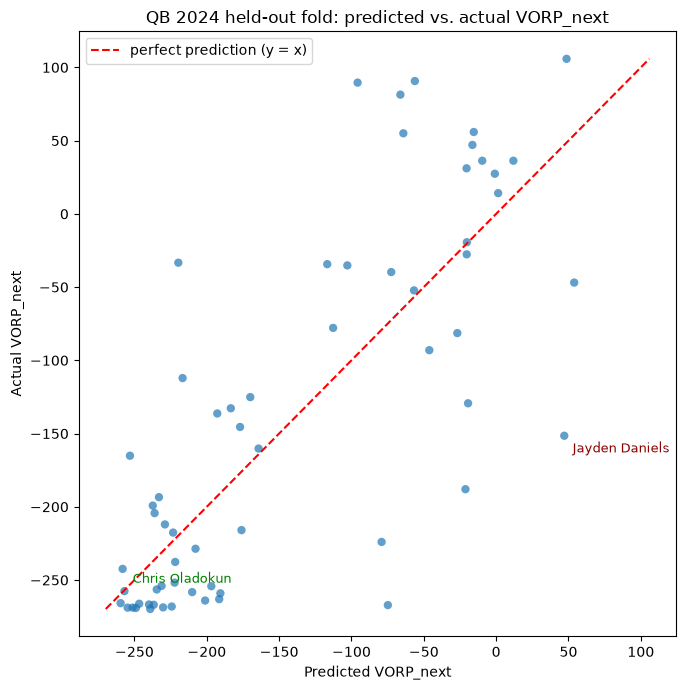

Best prediction:  Chris Oladokun -- predicted -256.9, actual -257.6, abs error 0.7
Worst miss:       Jayden Daniels -- predicted 47.1, actual -151.5, abs error 198.6


In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(results_2024["predicted_vorp_next"], results_2024["actual_vorp_next"], alpha=0.7, edgecolor="none")

lo = min(results_2024["predicted_vorp_next"].min(), results_2024["actual_vorp_next"].min())
hi = max(results_2024["predicted_vorp_next"].max(), results_2024["actual_vorp_next"].max())
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="perfect prediction (y = x)")

best = results_2024.iloc[0]
worst = results_2024.iloc[-1]
ax.annotate(best["player"], (best["predicted_vorp_next"], best["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, 6), fontsize=9, color="green")
ax.annotate(worst["player"], (worst["predicted_vorp_next"], worst["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, -12), fontsize=9, color="darkred")

ax.set_xlabel("Predicted VORP_next")
ax.set_ylabel("Actual VORP_next")
ax.set_title("QB 2024 held-out fold: predicted vs. actual VORP_next")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best prediction:  {best['player']} -- predicted {best['predicted_vorp_next']:.1f}, "
      f"actual {best['actual_vorp_next']:.1f}, abs error {best['abs_error']:.1f}")
print(f"Worst miss:       {worst['player']} -- predicted {worst['predicted_vorp_next']:.1f}, "
      f"actual {worst['actual_vorp_next']:.1f}, abs error {worst['abs_error']:.1f}")

### Best prediction and worst miss, by name

**Best prediction: Chris Oladokun** — predicted -256.9, actual -257.6 (abs error 0.7). An easy case for the model, not an impressive one: Oladokun was a deep, inactive-caliber backup in both his 2024 feature season and the 2025 season being predicted, so both his `scarcity_z` (far below replacement) and his realized outcome sit at the floor. The model didn't need to be clever here — it just correctly recognized "this player's situation isn't changing."

**Worst miss: Jayden Daniels** — predicted +47.1 (a solidly above-replacement season), actual -151.5 (a deeply below-replacement one) — a 198.6-point miss, easily the largest of any QB in this fold. The model's prediction was reasonable *given what it knew*: Daniels' 2024 rookie season (Offensive Rookie of the Year) was excellent, and `vorp_delta_yoy`/`scarcity_z` both pointed toward continued strong value. What actually happened in 2025 was a real, well-documented injury cascade, not a skill decline or a benching for poor play — Daniels was limited to 7 starts, missing 10 games across a knee sprain, a hamstring injury, and a dislocated elbow that ultimately ended his season, and Washington was shut out of the postseason at 5-12 with Marcus Mariota finishing the year at QB ([CBS Sports](https://www.cbssports.com/nfl/news/jayden-daniels-injury-news-shut-down-2025-season-commanders/), [OutKick](https://www.foxnews.com/outkick-sports/washington-commanders-bet-healthy-jayden-daniels-bounce-back-injury-plagued-2025-season)). This is exactly the kind of miss no feature set built from *last season's* stats can catch — none of QB's 6 features (age, draft capital, prior efficiency, prior scarcity) encode injury risk, so a season wiped out by a freak elbow dislocation reads to the model identically to unexplained variance. Worth remembering when interpreting this model's confidence on any single player, not just Daniels.